<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/class22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1000, 12)
   StudentID     Name  Gender  AttendanceRate  StudyHoursPerWeek  \
0        1.0     John    Male            85.0               15.0   
1        2.0    Sarah  Female            90.0               20.0   
2        3.0     Alex    Male            78.0               10.0   
3        4.0  Michael    Male            92.0               25.0   
4        5.0     Emma  Female             NaN               18.0   

   PreviousGrade  ExtracurricularActivities ParentalSupport  FinalGrade  \
0           78.0                        1.0            High        80.0   
1           85.0                        2.0          Medium        87.0   
2           65.0                        0.0             Low        68.0   
3           90.0                        3.0            High        92.0   
4           82.0                        2.0          Medium        85.0   

   Study Hours  Attendance (%) Online Classes Taken  
0          4.8            59.0                False  
1     

/tmp/ipykernel_252/3157324733.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[i] = df[i].fillna (mode_val)


Optimization terminated successfully.
         Current function value: 0.664764
         Iterations: 12
         Function evaluations: 13
         Gradient evaluations: 13

Model Summary:
                             OrderedModel Results                             
Dep. Variable:      Performance_Level   Log-Likelihood:                -465.33
Model:                   OrderedModel   AIC:                             950.7
Method:            Maximum Likelihood   BIC:                             996.2
Date:                Wed, 04 Mar 2026                                         
Time:                        16:38:53                                         
No. Observations:                 700                                         
Df Residuals:                     690                                         
Df Model:                           9                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

[[  0   0   0]
 [ 14 102   0]
 [ 12 172   0]]


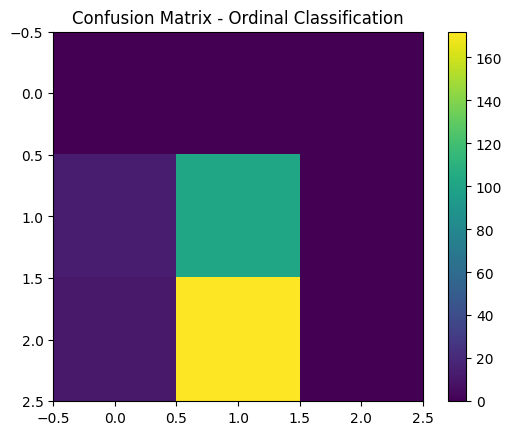

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/student_performance_updated_1000.csv')
df.head()

print("Dataset Shape:", df.shape)
print(df.head())

df = df.drop(columns=["StudentID", "Name"])

print("\nMissing Values Per Column:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()
print("Shape After Removing Duplicates:", df.shape)

#filling the missing values
for i in df.columns:
  if df[i].dtype in ['int64', 'float64']:
    med_val = df[i].median()
    df[i] = df[i].fillna(med_val)
  else:
    mode_val=df[i].mode()[0]
    df[i] = df[i].fillna (mode_val)
print("\nMissing Values Per Column:")
print(df.isnull().sum())

#gender-Binary encoding
df['Gender']=df["Gender"].map({"Male":0,"Female":1})

df["Online Classes Taken"]=df["Online Classes Taken"].astype(int)

df["ParentalSupport"]=df["ParentalSupport"].map({
    "Low":0,
    "Medium":1,
    "High":2

})

def categorize(score):
  if score<60:
    return 0
  elif score< 80:
    return 1
  else:
    return 2
df['Performance_Level']=df["FinalGrade"].apply(categorize)

#Drop original FinalGrade to prevent Leakage
df=df.drop(columns=["FinalGrade"])
print(df["Performance_Level"].value_counts())

X=df.drop(columns=["Performance_Level"])
y=df["Performance_Level"]

from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test=train_test_split(
X,y,test_size=0.3,random_state=42

)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

from statsmodels.miscmodels.ordinal_model import OrderedModel

#builidng the ordinal regression
model = OrderedModel(
  y_train,
  X_train_scaled,
  distr='logit'
)
result = model.fit(method='bfgs')
print("\nModel Summary:")
print(result.summary())

#prediction

pred_probs=result.predict(X_test_scaled)

#convert probability matrix into class labels
predicted_class=np.argmax(pred_probs,axis=1)

#evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test,predicted_class)

print("\nModel Accuracy:",accuracy)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predicted_class))
print("\nClassification Report:")
print(classification_report(y_test, predicted_class))



#15) Plot Confusion Matrix (Matplotlib)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, predicted_class)
plt.figure()
plt.imshow(cm, interpolation="nearest")

print(confusion_matrix(y_test, predicted_class))
plt.title("Confusion Matrix - Ordinal Classification")
plt.colorbar()
labels = ["Low (0)", "Med (1)", "High(2)"]
ticks=np.arange(len(labels))
plt.xticks=(ticks, labels)
plt.yticks=(ticks, labels)




In [ ]:
import pandas as pd
df=pd.read_csv('/content/Iris.csv')
df.head()

print(df.shape)
df.columns
df.info()
df.head(5)
duplicates=df.duplicated().sum()

import plotly.express as px
import matplotlib.pyplot as plt
fig=px.scatter(
  df,
  x='SepalLengthCm',
  y='SepalWidthCm',
  color='Species',
  title='Sepal Length vs Width'
)
fig.show()

y=df["Species"]
X=df.drop(columns=['Species','Id'])

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.3,random_state=42
)
print("\nTraining Size:",X_train.shape)
print("Testing Size:",X_test.shape)

(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB



Training Size: (105, 4)
Testing Size: (45, 4)
